# 01 — UC2 Centralized Baseline (DSCL)

Train a centralized LSTM model (Data-Sharing Centralized Learning)
as the upper-bound baseline. One model trained on all APs' data.

Since the centralized model doesn't depend on α (it sees all data),
we only need to run it once per alpha partition (the test split differs).

In [1]:
import sys, os
sys.path.append("..")
import UC2Utils as uc2
sys.path.insert(0, uc2.LIB_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from collections import Counter
import torch; print(torch.__version__)
import torchvision; print(torchvision.__version__)


sys.path.insert(0, uc2.LIB_DIR)

2.10.0+cu128
0.25.0+cu128


## Configuration

In [2]:
ALPHAS = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
MODEL = "lstm"

# Override any defaults here
OVERRIDES = dict(
    num_glob_iters=100,
    local_epochs=50,
    early_stopping_patience=50,
    batch_size=32,
)

## Train Centralized Model

The `Centralized` server aggregates ALL users' data into a single 
training set. We run it for each alpha because the data partition 
(and hence the test set) differs per alpha.

In [3]:
import torch
print(torch.cuda.get_device_name(0))
print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"Free VRAM:  {torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")

NVIDIA GeForce RTX 3050 Ti Laptop GPU
Total VRAM: 4.0 GB
Free VRAM:  3.2 GB


In [4]:
RETRAIN = False
results_centralized = {}

for alpha in ALPHAS:
    print(f"\n{'='*60}")
    print(f"  CENTRALIZED — α={alpha}")
    print(f"{'='*60}")
    
    if RETRAIN or not uc2.result_exists("Centralized", alpha):
        try:
            server, result = uc2.run_experiment(
                algorithm="Centralized",
                alpha=alpha,
                **OVERRIDES
            )
            results_centralized[alpha] = result
        except Exception as e:
            print(f"  [ERROR] {e}")
    else:
        print(f"  [✓] Already done — loading results.")
        results_centralized[alpha] = uc2.load_result("Centralized", alpha)


  CENTRALIZED — α=0.01
  [✓] Already done — loading results.

  CENTRALIZED — α=0.1
  [✓] Already done — loading results.

  CENTRALIZED — α=0.5
  [✓] Already done — loading results.

  CENTRALIZED — α=1.0
  [✓] Already done — loading results.

  CENTRALIZED — α=5.0
  [✓] Already done — loading results.

  CENTRALIZED — α=10.0
  [✓] Already done — loading results.


## Training Curves

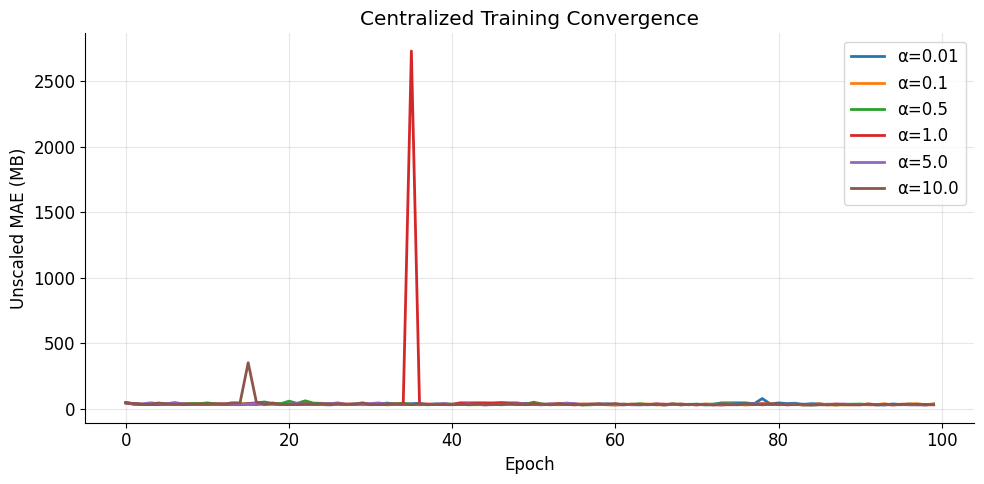

In [5]:
import matplotlib.pyplot as plt
uc2.setup_plot_style()

fig, ax = plt.subplots(figsize=(10, 5))
for alpha, r in sorted(results_centralized.items()):
    glob_metrics = r["metrics"].get("glob_test_metric", [])
    maes = [m.get("unscaled_mae") for m in glob_metrics]
    ax.plot(maes, label=f"α={alpha}", linewidth=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Unscaled MAE (MB)")
ax.set_title("Centralized Training Convergence")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

Centralized results saved to `results/centralized/alpha_{α}/lstm/rep_0/`.
These serve as the upper-bound baseline for comparison with FL methods.

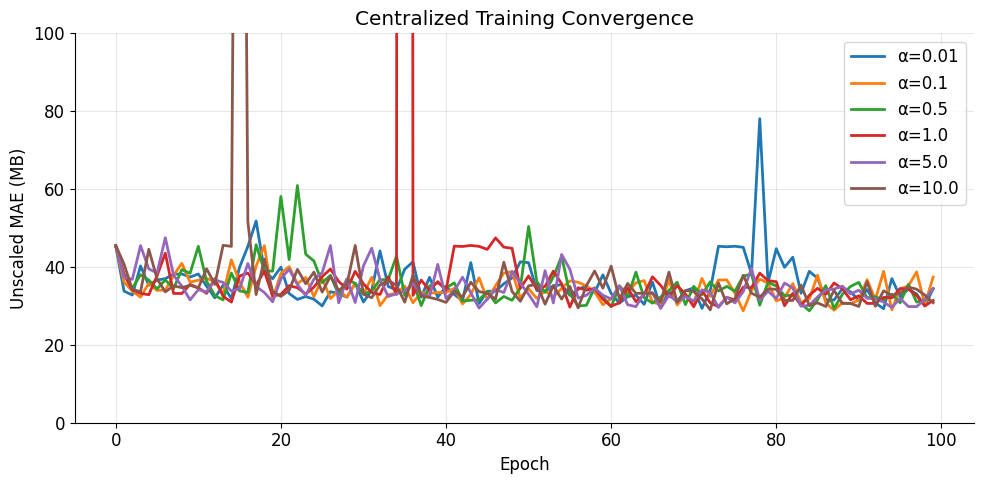

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for alpha, r in sorted(results_centralized.items()):
    glob_metrics = r["metrics"].get("glob_test_metric", [])
    maes = [m.get("unscaled_mae") for m in glob_metrics]
    ax.plot(maes, label=f"α={alpha}", linewidth=2)

ax.set_ylim(0, 100)  # clip to see the actual convergence
ax.set_xlabel("Epoch")
ax.set_ylabel("Unscaled MAE (MB)")
ax.set_title("Centralized Training Convergence")
ax.legend()
plt.tight_layout()
plt.show()